# 🧠 AI Resume Information Extraction System using Named Entity Recognition (NER)

**Fine-tuning DistilBERT for Token Classification on Resume Data**

[![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)](https://www.python.org/)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.x-red.svg)](https://pytorch.org/)
[![Transformers](https://img.shields.io/badge/🤗%20Transformers-latest-yellow.svg)](https://huggingface.co/docs/transformers)

---

This notebook builds a **complete, production-style NLP pipeline** that automatically extracts structured
information (names, emails, skills, degrees, companies, job titles, dates, locations, …) from raw resume text
by fine-tuning a **DistilBERT** transformer for **token classification**.

**How to run:** `Runtime ▸ Change runtime type ▸ GPU`, then `Runtime ▸ Run all`.
The only manual step is uploading the Kaggle Resume-NER dataset **ZIP file** when prompted in Section 3.

---

## 📑 Table of Contents

1. [Project Introduction](#intro)
2. [Install Dependencies](#install)
3. [ZIP Upload & Dataset Extraction](#upload)
4. [Import Libraries](#imports)
5. [Hardware Detection](#hardware)
6. [Load Dataset](#load)
7. [Exploratory Data Analysis](#eda)
8. [Data Cleaning](#cleaning)
9. [BIO Tag Processing](#bio)
10. [Tokenization](#tokenization)
11. [Dataset Preparation (Train/Val/Test)](#splits)
12. [Model Construction](#model)
13. [Training Configuration](#config)
14. [Model Training](#training)
15. [Evaluation](#evaluation)
16. [Training Curves](#curves)
17. [Error Analysis](#errors)
18. [Inference Pipeline](#inference)
19. [Export Results](#export)
20. [Save & Reload Model](#save)
21. [Demonstration](#demo)
22. [Model Discussion](#discussion)
23. [Future Improvements](#future)
24. [Conclusion](#conclusion)


<a name="intro"></a>
# 1. 📖 Project Introduction

## What is Named Entity Recognition (NER)?

**Named Entity Recognition** is the NLP task of locating and classifying spans of text into predefined
categories — people, organizations, locations, dates, skills, and so on. Given the sentence:

> *"Jane Doe worked as a Data Scientist at Google in Toronto from 2019 to 2023."*

a resume-NER model should extract:

| Span | Entity Type |
|---|---|
| Jane Doe | **Name** |
| Data Scientist | **Job Title / Designation** |
| Google | **Company** |
| Toronto | **Location** |
| 2019 to 2023 | **Dates / Experience** |

## NER as Token Classification

Modern transformer-based NER is framed as **token classification**: every token in the input receives a
label. Multi-token entities are encoded with the **BIO scheme** (covered in depth in Section 9):
`B-` marks the *Beginning* of an entity, `I-` marks tokens *Inside* it, and `O` marks everything *Outside*
any entity. The model is simply a transformer encoder with a linear classification head that predicts one
label per token — the same architecture family used for part-of-speech tagging and chunking.

## Why Resume Parsing?

Recruiters and Applicant Tracking Systems (ATS) receive **thousands of resumes per job posting**, each in a
different layout and writing style. Manually reading them does not scale. An automated resume-extraction
system converts unstructured text into structured, queryable records, enabling:

* **Candidate search & ranking** — "find all candidates with a Master's degree and PyTorch experience".
* **ATS auto-fill** — populating application forms directly from an uploaded resume.
* **Talent analytics** — aggregate views of skills, education, and experience across a candidate pool.
* **De-duplication & compliance** — consistent structured records instead of free text.

Companies like LinkedIn, Workday, Greenhouse, and Lever all run production resume-parsing pipelines; this
notebook builds a small-scale but architecturally faithful version of such a system.

## Project Objectives

1. Ingest the Kaggle **Resume NER Training Dataset** fully automatically from an uploaded ZIP.
2. Explore, clean, and convert the data into token-level **BIO** format.
3. Fine-tune **DistilBERT** for token classification with Hugging Face `Trainer`.
4. Evaluate rigorously with **entity-level precision / recall / F1** (`seqeval`).
5. Perform **error analysis** and build a **reusable inference pipeline** with confidence scores.
6. Export predictions to **JSON/CSV** and persist the model for future use.


<a name="install"></a>
# 2. 📦 Install Dependencies

**What & why:** Google Colab ships with `torch`, `pandas`, `numpy`, `matplotlib`, and `scikit-learn`
pre-installed, so we only add the Hugging Face ecosystem (`transformers`, `datasets`, `evaluate`,
`accelerate`) plus `seqeval`, the standard library for **entity-level** NER metrics.

**Best practice:** install *only* what you need (smaller attack surface, faster startup, fewer version
conflicts) and use `-q` to keep logs readable.

**Common pitfall:** mixing old cached versions of `transformers` and `accelerate` causes cryptic `Trainer`
errors — `-U` upgrades both together so their APIs stay in sync.

In [1]:
# Install only the packages Colab does not already provide.
!pip install -q -U transformers datasets evaluate seqeval accelerate

# Quick sanity check of the environment.
import transformers, datasets, torch
print(f"transformers : {transformers.__version__}")
print(f"datasets     : {datasets.__version__}")
print(f"torch        : {torch.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.8 MB/s eta 0:00:00
transformers : 5.13.0
datasets     : 5.0.0
torch        : 2.11.0+cu128


<a name="upload"></a>
# 3. 📂 ZIP Upload & Dataset Extraction

**What happens here:** you upload the dataset ZIP once; everything downstream is automatic —
extraction, directory-tree display, and dataset-file detection. No path editing required.

**Why it matters:** hard-coded paths are the #1 reason shared notebooks fail on other machines.
We use `pathlib` + recursive search so the notebook works regardless of how the ZIP is structured
(flat files, nested folders, renamed archives).

**Common pitfalls handled:**
* ZIPs that extract into a nested folder (or several levels of them).
* Multiple candidate files — we rank candidates by extension and filename keywords.
* Running outside Colab — we fall back to scanning the working directory for a ZIP.

In [2]:
import zipfile
import shutil
from pathlib import Path

# ---------------------------------------------------------------- upload
DATA_DIR = Path("resume_ner_data")

def upload_zip() -> Path:
    """Prompt for a ZIP upload in Colab; fall back to any ZIP already on disk."""
    try:
        from google.colab import files  # only available inside Colab
        print("⬆️  Please upload the Resume NER dataset ZIP file …")
        uploaded = files.upload()
        zips = [Path(name) for name in uploaded if name.lower().endswith(".zip")]
        if not zips:
            raise FileNotFoundError(
                "No .zip file was uploaded. Please re-run this cell and select the dataset ZIP."
            )
        return zips[0]
    except ImportError:
        # Not running in Colab — look for a ZIP in the current directory instead.
        local = sorted(Path(".").glob("*.zip"))
        if not local:
            raise FileNotFoundError(
                "Not running in Colab and no .zip found in the working directory."
            )
        print(f"ℹ️  Colab upload unavailable — using local file: {local[0].name}")
        return local[0]

zip_path = upload_zip()
print(f"\n✅ ZIP detected: {zip_path.name} ({zip_path.stat().st_size / 1e6:.2f} MB)")

# ---------------------------------------------------------------- extract
if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)          # fresh extraction on every run (idempotent cell)
DATA_DIR.mkdir(parents=True)

try:
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR)
except zipfile.BadZipFile as err:
    raise RuntimeError(f"'{zip_path.name}' is not a valid ZIP archive.") from err

print(f"✅ Extracted to: {DATA_DIR.resolve()}")

⬆️  Please upload the Resume NER dataset ZIP file …


Saving archive.zip to archive.zip

✅ ZIP detected: archive.zip (14.91 MB)
✅ Extracted to: /content/resume_ner_data


In [3]:
# ---------------------------------------------------------------- directory tree
def print_tree(root: Path, max_depth: int = 4, max_entries: int = 40) -> None:
    """Pretty-print the extracted directory tree (depth/entry limited)."""
    print(f"📁 {root}/")
    shown = 0
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        shown += 1
        if shown > max_entries:
            print("   … (truncated)")
            break
        indent = "    " * depth
        icon = "📁" if path.is_dir() else "📄"
        size = "" if path.is_dir() else f"  ({path.stat().st_size / 1e3:.1f} KB)"
        print(f"{indent}{icon} {path.name}{size}")

print_tree(DATA_DIR)

# ---------------------------------------------------------------- dataset detection
DATA_EXTENSIONS = {".json", ".jsonl", ".csv", ".tsv", ".conll", ".txt"}
NAME_KEYWORDS   = ("resume", "ner", "entit", "train", "annot", "data")
EXCLUDE_NAMES   = ("metadata", "readme", "license", "citation")   # Kaggle housekeeping files

def find_dataset_files(root: Path) -> list[Path]:
    """Locate candidate dataset files anywhere under `root`, best candidates first."""
    candidates = [
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in DATA_EXTENSIONS
        and not p.name.startswith((".", "_")) and p.stat().st_size > 0
        and not any(x in p.name.lower() for x in EXCLUDE_NAMES)
    ]
    if not candidates:
        raise FileNotFoundError(
            f"No dataset files with extensions {sorted(DATA_EXTENSIONS)} were found "
            f"under '{root}'. Please verify the ZIP contains the Kaggle Resume NER data."
        )

    def score(p: Path) -> tuple:
        name = p.name.lower()
        kw_hits = sum(kw in name for kw in NAME_KEYWORDS)
        ext_rank = {".json": 3, ".jsonl": 3, ".csv": 2, ".tsv": 2, ".conll": 2, ".txt": 1}
        return (kw_hits, ext_rank.get(p.suffix.lower(), 0), p.stat().st_size)

    return sorted(candidates, key=score, reverse=True)

dataset_files = find_dataset_files(DATA_DIR)
PRIMARY_FILE = dataset_files[0]

print("\n🔎 Detected dataset file(s), ranked by likelihood:")
for i, f in enumerate(dataset_files[:8]):
    marker = "⭐ PRIMARY" if i == 0 else ""
    print(f"   {i + 1}. {f.relative_to(DATA_DIR)}  ({f.stat().st_size / 1e3:.1f} KB) {marker}")
print(f"\n✅ Primary dataset file: {PRIMARY_FILE}")

📁 resume_ner_data/
    📄 README.md  (2.3 KB)
    📄 dataset-metadata.json  (0.5 KB)
    📄 sample.json  (22.5 KB)
    📄 train.json  (63299.3 KB)

🔎 Detected dataset file(s), ranked by likelihood:
   1. train.json  (63299.3 KB) ⭐ PRIMARY
   2. sample.json  (22.5 KB) 

✅ Primary dataset file: resume_ner_data/train.json


<a name="imports"></a>
# 4. 📚 Import Libraries

**Organization principle (PEP 8):** standard library → third-party scientific stack → deep-learning /
Hugging Face libraries. Grouped imports make dependencies obvious to reviewers, and importing everything in
one place makes the rest of the notebook cleaner. We also fix **all random seeds** here — Python, NumPy, and
PyTorch — which is essential for reproducible experiments (a hallmark of professional ML work).

In [4]:
# ----------------------------- standard library
import json
import random
import re
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

# ----------------------------- scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ----------------------------- deep learning / Hugging Face
import torch
import evaluate
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)

# ----------------------------- global reproducibility
SEED = 42

def set_all_seeds(seed: int = SEED) -> None:
    """Seed Python, NumPy, and PyTorch (CPU + CUDA) for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)          # Hugging Face convenience wrapper (also seeds Trainer workers)

set_all_seeds()
print(f"✅ Libraries imported — global seed set to {SEED}")

✅ Libraries imported — global seed set to 42


<a name="hardware"></a>
# 5. 🖥️ Hardware Detection

**Why it matters:** fine-tuning a transformer on CPU takes hours; on a free Colab T4 GPU it takes minutes.
We detect the accelerator once, store it in a global `DEVICE`, and enable **mixed-precision (fp16)** training
later only when a GPU is present — fp16 roughly halves memory use and speeds up training on modern GPUs.

**Common pitfall:** forgetting to move *both* the model and the input tensors to the same device causes the
classic `Expected all tensors to be on the same device` error. The HF `Trainer` handles model placement
automatically, but our custom inference code (Section 18) must do it explicitly.

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("HARDWARE REPORT")
print("=" * 60)
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"✅ GPU detected : {props.name}")
    print(f"   VRAM         : {props.total_memory / 1e9:.1f} GB")
    print(f"   CUDA version : {torch.version.cuda}")
else:
    print("⚠️  No GPU detected — training will run on CPU and be MUCH slower.")
    print("   In Colab: Runtime ▸ Change runtime type ▸ Hardware accelerator ▸ GPU")
print(f"   Device in use: {DEVICE}")
print("=" * 60)

HARDWARE REPORT
✅ GPU detected : Tesla T4
   VRAM         : 15.6 GB
   CUDA version : 12.8
   Device in use: cuda


<a name="load"></a>
# 6. 📥 Load Dataset

Kaggle hosts several mirrors of resume NER data, and they do **not** share one format. The common ones:

* **spaCy training format** — one JSON array of `["resume text", {"entities": [[start, end, "LABEL"], …]}]`
  pairs (this is what files named `train.json` usually contain).
* **Dataturks JSON Lines** — one object per line with `content` and `annotation` (spans under `points`,
  with *inclusive* end offsets — a classic off-by-one trap).
* **doccano exports** — `{"text": …, "labels": [[start, end, "LABEL"]]}` or
  `{"entities": [{"start_offset": …, "end_offset": …, "label": …}]}`.
* **CSV** (token/tag columns) or **CoNLL** text.

**Design decision:** rather than assuming one format, we implement a **universal JSON loader** that
normalizes *all* of the span-based JSON variants above (plus wrapper dicts like `{"data": [...]}`), and
separate CSV/CoNLL loaders. Every loader converts its input to a single **unified internal representation**:

```python
{"tokens": ["Jane", "Doe", "…"], "ner_tags": ["B-Name", "I-Name", "O", …]}
```

For the JSON format this requires converting **character-level spans → token-level BIO tags**, done by
tokenizing the text with offsets (`re.finditer(r"\S+")`) and checking which tokens overlap each span —
a very common real-world preprocessing task worth understanding in detail.

**Pitfall handled:** annotations in this dataset sometimes include leading/trailing whitespace or overlap
each other; overlapping tokens keep the *first* label assigned (first-come-first-served), and labels are
sanitized (`"Email Address" → "Email_Address"`) so they are valid BIO tag suffixes.

In [6]:
def sanitize_label(label: str) -> str:
    """Normalize an entity label: trim, collapse whitespace to underscores."""
    return re.sub(r"\s+", "_", label.strip())


def spans_to_bio(text: str, spans: list[dict]) -> dict[str, list[str]] | None:
    """Convert character-offset entity spans into token-level BIO tags.

    `spans` items look like {"start": int, "end": int, "label": str}.
    Returns None for empty/unusable documents.
    """
    if not isinstance(text, str) or not text.strip():
        return None

    # Sanitize unpaired Unicode surrogates (e.g. a broken half of an emoji escape
    # in the source JSON). They are valid in Python str but ILLEGAL UTF-8, so
    # PyArrow / HF Datasets would crash on them later. 'replace' maps each lone
    # surrogate to a single '?', so every character offset stays exactly aligned
    # with the annotation spans.
    text = text.encode("utf-8", "replace").decode("utf-8")

    matches = list(re.finditer(r"\S+", text))       # simple whitespace tokenizer w/ offsets
    tokens  = [m.group() for m in matches]
    tags    = ["O"] * len(tokens)

    for span in sorted(spans, key=lambda s: s["start"]):
        label = sanitize_label(span["label"])
        began = False
        for i, m in enumerate(matches):
            # token overlaps the span AND has not been claimed by an earlier span
            if m.start() < span["end"] and m.end() > span["start"] and tags[i] == "O":
                tags[i] = f"{'I' if began else 'B'}-{label}"
                began = True
    return {"tokens": tokens, "ner_tags": tags}


# ---------------------------------------------------------------- loader 1: universal JSON
def _norm_entity(e) -> list[dict]:
    """Normalize ONE annotation element (any known shape) → [{'start','end','label'}, ...].

    Handles: spaCy/doccano triples [start, end, label]; flat dicts with
    start/end or start_offset/end_offset; Dataturks dicts with 'points'
    (whose 'end' is INCLUSIVE → +1 to convert to Python-style exclusive).
    """
    out = []
    if isinstance(e, (list, tuple)) and len(e) >= 3 and isinstance(e[0], (int, float)):
        out.append({"start": int(e[0]), "end": int(e[1]), "label": str(e[2])})
    elif isinstance(e, dict):
        label = (e.get("label") or e.get("labels") or e.get("tag")
                 or e.get("type") or e.get("entity"))
        if isinstance(label, (list, tuple)):
            label = label[0] if label else None
        if "points" in e:                                   # Dataturks
            for pt in (e.get("points") or []):
                if (isinstance(pt, dict) and label
                        and pt.get("start") is not None and pt.get("end") is not None):
                    out.append({"start": int(pt["start"]),
                                "end": int(pt["end"]) + 1,   # inclusive → exclusive
                                "label": str(label)})
        else:                                               # doccano / generic span dicts
            start = e.get("start", e.get("start_offset"))
            end   = e.get("end",   e.get("end_offset"))
            if label and start is not None and end is not None:
                out.append({"start": int(start), "end": int(end), "label": str(label)})
    return out


def _extract_doc(item) -> tuple[str, list[dict]] | None:
    """Turn one raw JSON item into (text, spans), or None if unrecognizable."""
    # spaCy pair: ["resume text", {"entities": [[s, e, label], ...]}]
    if (isinstance(item, (list, tuple)) and len(item) == 2
            and isinstance(item[0], str) and isinstance(item[1], dict)):
        ents = item[1].get("entities") or item[1].get("labels") or []
        return item[0], [s for e in ents for s in _norm_entity(e)]
    # dict styles: Dataturks / doccano / generic
    if isinstance(item, dict):
        text = item.get("content") or item.get("text") or item.get("document")
        if not isinstance(text, str):
            return None
        raw = (item.get("annotation") or item.get("annotations") or item.get("entities")
               or item.get("labels") or item.get("label") or item.get("spans") or [])
        if isinstance(raw, dict):                           # e.g. {"entities": [...]}
            raw = raw.get("entities") or raw.get("labels") or []
        if not isinstance(raw, list):
            raw = []
        return text, [s for e in raw for s in _norm_entity(e)]
    return None


def load_json_ner(path: Path) -> list[dict]:
    """Universal JSON loader: whole-file JSON (array / wrapper dict) or JSON Lines."""
    text = path.read_text(encoding="utf-8", errors="replace").strip()

    # 1) Try the whole file as one JSON document first (spaCy format is one big array).
    items: list = []
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            items = parsed
        elif isinstance(parsed, dict):
            for key in ("data", "annotations", "examples", "train",
                        "items", "documents", "records"):
                if isinstance(parsed.get(key), list):
                    items = parsed[key]
                    break
            else:
                items = [parsed]
    except json.JSONDecodeError:
        # 2) Fall back to JSON Lines (Dataturks / doccano exports).
        for line in text.splitlines():
            line = line.strip().rstrip(",")
            if not line or line in ("[", "]", "{", "}"):
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            if isinstance(obj, (dict, list)):               # skip bare strings/numbers
                items.append(obj)

    records = []
    for item in items:
        doc = _extract_doc(item)
        if doc is None:
            continue
        rec = spans_to_bio(doc[0], doc[1])
        if rec:
            records.append(rec)
    return records


# ---------------------------------------------------------------- loader 2: CoNLL text
def load_conll(path: Path) -> list[dict]:
    """Load CoNLL format: 'token TAG' per line, blank line between sequences."""
    records, tokens, tags = [], [], []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        line = line.strip()
        if not line:
            if tokens:
                records.append({"tokens": tokens, "ner_tags": tags})
                tokens, tags = [], []
            continue
        parts = line.split()
        if len(parts) >= 2:
            tokens.append(parts[0])
            tags.append(sanitize_label(parts[-1]) if parts[-1] != "O" else "O")
    if tokens:
        records.append({"tokens": tokens, "ner_tags": tags})
    return records


# ---------------------------------------------------------------- loader 3: token/tag CSV
def load_csv(path: Path) -> list[dict]:
    """Load CSVs with (sentence_id, token, tag)-style columns."""
    df = pd.read_csv(path, encoding="utf-8", encoding_errors="replace",
                     on_bad_lines="skip")
    cols = {c.lower().strip(): c for c in df.columns}
    tok_col = next((cols[c] for c in cols if c in {"token", "word", "words", "text"}), None)
    tag_col = next((cols[c] for c in cols if c in {"tag", "label", "labels", "ner_tag", "ner"}), None)
    sid_col = next((cols[c] for c in cols if "sentence" in c or c in {"doc_id", "id"}), None)
    if tok_col is None or tag_col is None:
        return []
    if sid_col is not None:
        df[sid_col] = df[sid_col].ffill()
        groups = df.groupby(sid_col, sort=False)
    else:
        groups = [(0, df)]
    records = []
    for _, g in groups:
        tokens = [str(t) for t in g[tok_col].tolist()]
        tags   = [str(t) if str(t) != "O" else "O" for t in g[tag_col].tolist()]
        if tokens:
            records.append({"tokens": tokens, "ner_tags": tags})
    return records


# ---------------------------------------------------------------- unified auto-loader
def load_dataset_auto(files_ranked: list[Path]) -> tuple[list[dict], Path]:
    """Try every candidate file with every applicable loader; return first success."""
    for f in files_ranked:
        suffix = f.suffix.lower()
        loaders = {".json": [load_json_ner],
                   ".jsonl": [load_json_ner],
                   ".csv":  [load_csv],
                   ".tsv":  [load_csv],
                   ".conll": [load_conll],
                   ".txt":  [load_conll, load_json_ner]}.get(suffix, [])
        for loader in loaders:
            try:
                recs = loader(f)
            except Exception as err:
                print(f"   ⚠️ {loader.__name__} failed on {f.name}: {err}")
                continue
            # accept only if we got real annotated data (some non-O tags present)
            if recs and any(t != "O" for r in recs[:200] for t in r["ner_tags"]):
                return recs, f
            print(f"   ℹ️ {loader.__name__} found no annotated records in {f.name}")

    # -------- diagnostics: show the structure of the best candidate to aid debugging
    print("\n🔍 DIAGNOSTIC — first 400 characters of the top candidate file:")
    try:
        print(files_ranked[0].read_text(encoding="utf-8", errors="replace")[:400])
    except Exception:
        pass
    raise RuntimeError(
        "Could not parse any candidate file as NER data. Supported formats: spaCy "
        "JSON, Dataturks JSONL, doccano JSON(L), CoNLL, and token/tag CSV. "
        "Files tried: " + ", ".join(str(f.name) for f in files_ranked[:5])
    )

records, source_file = load_dataset_auto(dataset_files)
print(f"✅ Loaded {len(records)} annotated resume documents from '{source_file.name}'")

✅ Loaded 5960 annotated resume documents from 'train.json'


In [7]:
# ---------------------------------------------------------------- initial inspection
df_overview = pd.DataFrame({
    "n_tokens":   [len(r["tokens"]) for r in records],
    "n_entities": [sum(t.startswith("B-") for t in r["ner_tags"]) for r in records],
})

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Documents (rows)     : {len(records)}")
print(f"Columns per record   : tokens (list[str]), ner_tags (list[str])")
print(f"Total tokens         : {df_overview.n_tokens.sum():,}")
print(f"Total entities       : {df_overview.n_entities.sum():,}")
print(f"Missing/empty docs   : {sum(len(r['tokens']) == 0 for r in records)}")
print(f"Data types           : tokens={type(records[0]['tokens'][0]).__name__}, "
      f"tags={type(records[0]['ner_tags'][0]).__name__}")

print("\n--- Per-document statistics ---")
print(df_overview.describe().round(1))

# Label distribution (entity types only, counted once per entity via B- tags)
entity_counts = Counter(t[2:] for r in records for t in r["ner_tags"] if t.startswith("B-"))
print("\n--- Entity label distribution ---")
for label, count in entity_counts.most_common():
    print(f"   {label:<25s} {count:>6,}")

# Sample rows: first 15 (token, tag) pairs of the first document
print("\n--- Sample (document 0, first 15 tokens) ---")
sample = records[0]
print(pd.DataFrame({"token": sample["tokens"][:15], "tag": sample["ner_tags"][:15]})
      .to_string(index=False))

DATASET OVERVIEW
Documents (rows)     : 5960
Columns per record   : tokens (list[str]), ner_tags (list[str])
Total tokens         : 3,452,763
Total entities       : 507,530
Missing/empty docs   : 0
Data types           : tokens=str, tags=str

--- Per-document statistics ---
       n_tokens  n_entities
count    5960.0      5960.0
mean      579.3        85.2
std       593.2        58.8
min         4.0         1.0
25%       270.0        42.0
50%       447.0        71.0
75%       735.0       117.0
max     15081.0       540.0

--- Entity label distribution ---
   SKILL                     477,640
   OTHER                     10,118
   DESIGNATION                4,267
   LOCATION                   4,063
   EXPERIENCE                 3,536
   PERSON                     3,117
   EDUCATION                  2,116
   EXPERTISE                  1,044
   EMAIL                        813
   COMPANY                      217
   COLLABORATION                186
   LANGUAGE                     158
   AC

<a name="eda"></a>
# 7. 📊 Exploratory Data Analysis (EDA)

**Purpose:** before touching a model, we need to understand the *shape* of the data — how many entities of
each type exist, how long resumes are, and how imbalanced the label space is. These facts directly drive
modelling decisions:

* **Sequence length** determines our tokenizer `max_length` and whether long resumes must be **chunked**.
* **Class imbalance** (the `O` tag typically dominates >80% of tokens) explains why plain *token accuracy*
  is a misleading metric and why we evaluate with **entity-level F1** instead.
* **Rare entity types** warn us in advance which classes will have noisy precision/recall.

All plots use **matplotlib only**, with titles, axis labels, grids, and `tight_layout()` — the minimum bar
for portfolio-quality figures.

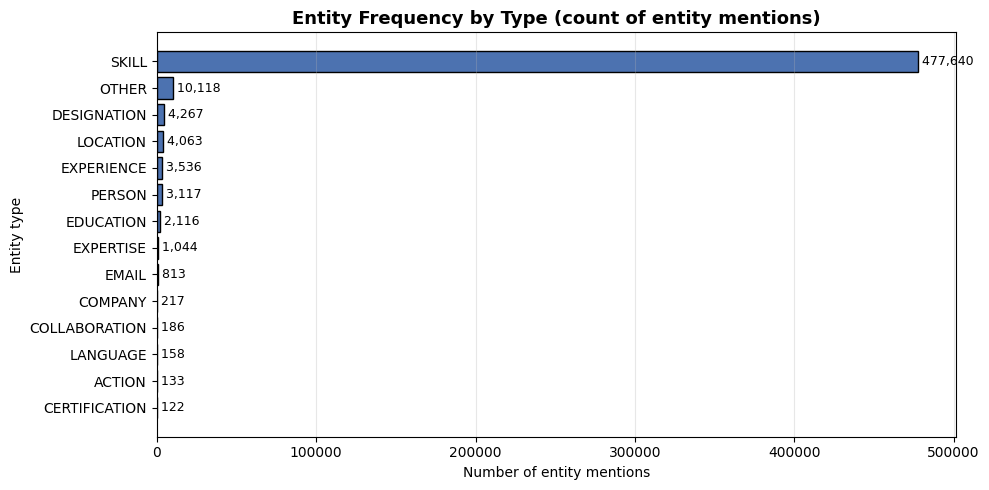

In [8]:
# ---------------------------------------------------------------- 7.1 entity frequency
labels_sorted = [l for l, _ in entity_counts.most_common()]
values_sorted = [entity_counts[l] for l in labels_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels_sorted[::-1], values_sorted[::-1], color="#4C72B0", edgecolor="black")
ax.set_title("Entity Frequency by Type (count of entity mentions)", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of entity mentions")
ax.set_ylabel("Entity type")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(values_sorted[::-1]):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation:** a handful of entity types (typically *Skills*, *Name*, *Designation*, *Company*)
dominate, while others (e.g. *Email Address*, *Graduation Year*) are rare. Expect noticeably lower and
noisier F1 on the rare classes — the model simply sees fewer training examples of them.

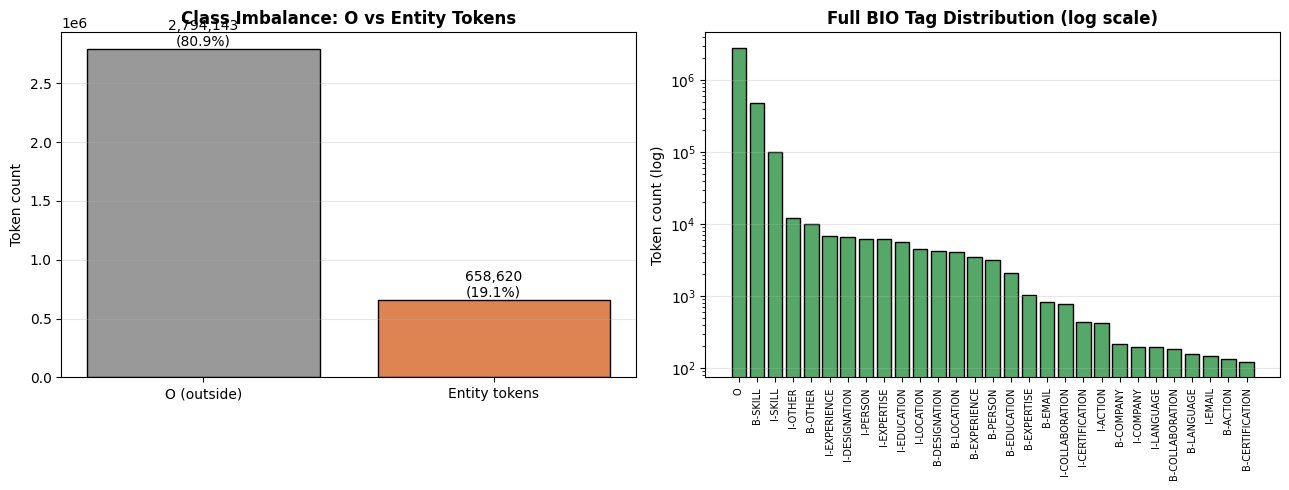

'O' tokens make up 80.9% of the corpus — a naive model predicting only 'O' would score high token accuracy but 0 F1.


In [9]:
# ---------------------------------------------------------------- 7.2 BIO tag distribution
tag_counter = Counter(t for r in records for t in r["ner_tags"])
o_count      = tag_counter.get("O", 0)
entity_toks  = sum(v for k, v in tag_counter.items() if k != "O")
total_toks   = o_count + entity_toks

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: O vs entity tokens — the core class-imbalance picture
axes[0].bar(["O (outside)", "Entity tokens"], [o_count, entity_toks],
            color=["#999999", "#DD8452"], edgecolor="black")
axes[0].set_title("Class Imbalance: O vs Entity Tokens", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Token count")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate([o_count, entity_toks]):
    axes[0].text(i, v, f"{v:,}\n({v / total_toks:.1%})", ha="center", va="bottom", fontsize=10)

# Right: full BIO tag distribution on a log scale (imbalance across all tags)
bio_labels = [k for k, _ in tag_counter.most_common()]
bio_values = [tag_counter[k] for k in bio_labels]
axes[1].bar(range(len(bio_labels)), bio_values, color="#55A868", edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_xticks(range(len(bio_labels)))
axes[1].set_xticklabels(bio_labels, rotation=90, fontsize=7)
axes[1].set_title("Full BIO Tag Distribution (log scale)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Token count (log)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"'O' tokens make up {o_count / total_toks:.1%} of the corpus — "
      "a naive model predicting only 'O' would score high token accuracy but 0 F1.")

**Interpretation:** the `O` class overwhelms everything else — the classic NER imbalance. This is
exactly why Section 15 reports **entity-level precision/recall/F1 via `seqeval`**: an entity only counts as
correct if its *entire span and type* match, making the metric immune to `O`-inflation.

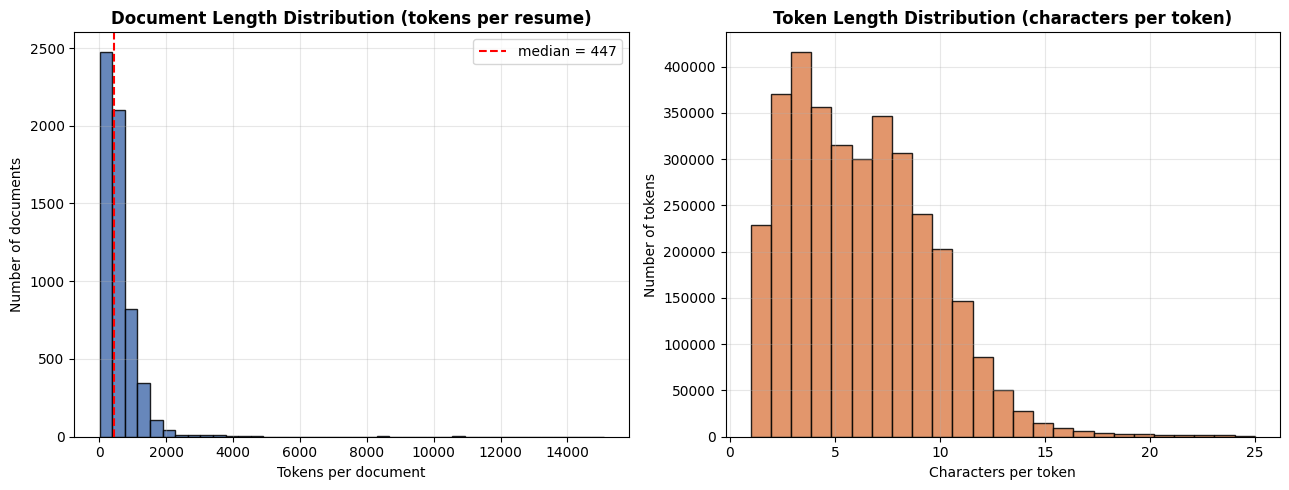

Document length — mean: 579, median: 447, 95th pct: 1358, max: 15081


In [10]:
# ---------------------------------------------------------------- 7.3 length distributions
doc_lengths  = df_overview["n_tokens"]
tok_lengths  = pd.Series([len(t) for r in records for t in r["tokens"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(doc_lengths, bins=40, color="#4C72B0", edgecolor="black", alpha=0.85)
axes[0].axvline(doc_lengths.median(), color="red", linestyle="--",
                label=f"median = {doc_lengths.median():.0f}")
axes[0].set_title("Document Length Distribution (tokens per resume)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Tokens per document")
axes[0].set_ylabel("Number of documents")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(tok_lengths[tok_lengths <= 25], bins=25, color="#DD8452",
             edgecolor="black", alpha=0.85)
axes[1].set_title("Token Length Distribution (characters per token)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Characters per token")
axes[1].set_ylabel("Number of tokens")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Document length — mean: {doc_lengths.mean():.0f}, median: {doc_lengths.median():.0f}, "
      f"95th pct: {doc_lengths.quantile(0.95):.0f}, max: {doc_lengths.max()}")

**Interpretation:** full resumes are typically **hundreds of tokens long**, far beyond a transformer's
comfortable window once WordPiece subwords are added (DistilBERT's hard limit is 512). Truncating would throw
away most of each resume's annotations, so in Section 8 we **chunk** long documents into overlapping-free
windows of ≤150 words — each chunk becomes an independent training example, preserving nearly all labels.

<a name="cleaning"></a>
# 8. 🧹 Data Cleaning

**Purpose:** real annotated datasets are messy. This one is known to contain duplicated resumes, stray
whitespace tokens, occasional empty documents, and a few inconsistent labels. Feeding noise into
fine-tuning both wastes capacity and — in the case of duplicates — **leaks data between train and test
splits**, silently inflating evaluation scores.

**Cleaning steps (each one explained inline):**
1. **Whitespace & encoding normalization** — drop tokens that are empty after stripping, and replace
   *unpaired Unicode surrogates* (broken halves of emoji escape sequences that appear in this dataset's
   JSON) with `?` — lone surrogates are valid in Python strings but illegal UTF-8, and would crash
   PyArrow / HF `Datasets` downstream.
2. **Invalid label repair** — any tag that is not `O` or valid `B-X`/`I-X` is reset to `O`.
3. **BIO consistency repair** — an `I-X` that does not follow `B-X`/`I-X` is promoted to `B-X`
   (a standard fix; `seqeval` otherwise miscounts such "dangling" entities).
4. **Empty-document removal** — documents with no tokens contribute nothing.
5. **Exact-duplicate removal** — identical resumes are dropped *before* splitting to prevent leakage.
6. **Consistency check** — assert `len(tokens) == len(ner_tags)` for every document.
7. **Chunking** — split documents into windows of ≤150 words so no annotation is lost to truncation
   (chunk boundaries are placed at `O` tokens where possible so entities are never split mid-span).

In [11]:
MAX_WORDS_PER_CHUNK = 150   # keeps WordPiece length safely under DistilBERT's 512 limit

VALID_TAG_RE = re.compile(r"^(O|[BI]-[A-Za-z0-9_]+)$")

def clean_record(rec: dict) -> dict | None:
    """Apply steps 1-3 to a single record; return None if it becomes empty."""
    tokens, tags = [], []
    for tok, tag in zip(rec["tokens"], rec["ner_tags"]):
        tok = tok.strip()                                    # (1) whitespace
        # (1b) strip lone Unicode surrogates — illegal UTF-8, crashes PyArrow later
        tok = tok.encode("utf-8", "replace").decode("utf-8")
        if not tok:
            continue
        if not VALID_TAG_RE.match(tag):                      # (2) invalid labels → O
            tag = "O"
        tokens.append(tok)
        tags.append(tag)
    # (3) BIO consistency: I-X must continue a B-X/I-X of the same type
    for i, tag in enumerate(tags):
        if tag.startswith("I-"):
            prev = tags[i - 1] if i > 0 else "O"
            if prev[2:] != tag[2:] or prev == "O":
                tags[i] = "B-" + tag[2:]
    if not tokens:                                           # (4) empty document
        return None
    assert len(tokens) == len(tags), "token/tag misalignment"  # (6) consistency
    return {"tokens": tokens, "ner_tags": tags}


def chunk_record(rec: dict, max_words: int = MAX_WORDS_PER_CHUNK) -> list[dict]:
    """(7) Split a long document into chunks of <= max_words, never inside an entity."""
    tokens, tags = rec["tokens"], rec["ner_tags"]
    chunks, start = [], 0
    while start < len(tokens):
        end = min(start + max_words, len(tokens))
        # back off the boundary so we don't cut an entity in half
        while end < len(tokens) and tags[end].startswith("I-") and end > start + 1:
            end -= 1
        chunks.append({"tokens": tokens[start:end], "ner_tags": tags[start:end]})
        start = end
    return chunks


# ---------------------------------------------------------------- run the pipeline
n_before = len(records)
cleaned = [c for r in records if (c := clean_record(r)) is not None]

# (5) exact-duplicate removal (hash of the full token sequence)
seen, deduped = set(), []
for r in cleaned:
    key = hash(" ".join(r["tokens"]))
    if key not in seen:
        seen.add(key)
        deduped.append(r)

chunked = [c for r in deduped for c in chunk_record(r)]

invalid_fixed = sum(
    1 for r in records for t in r["ner_tags"] if not VALID_TAG_RE.match(t)
)

print("=" * 60)
print("CLEANING REPORT")
print("=" * 60)
print(f"Documents before cleaning     : {n_before}")
print(f"Empty documents removed       : {n_before - len(cleaned)}")
print(f"Exact duplicates removed      : {len(cleaned) - len(deduped)}")
print(f"Invalid labels repaired → 'O' : {invalid_fixed}")
print(f"Documents after de-dup        : {len(deduped)}")
print(f"Chunks after windowing (≤{MAX_WORDS_PER_CHUNK}) : {len(chunked)}")
print(f"Max chunk length              : {max(len(c['tokens']) for c in chunked)} words")

records_clean = chunked

CLEANING REPORT
Documents before cleaning     : 5960
Empty documents removed       : 0
Exact duplicates removed      : 1774
Invalid labels repaired → 'O' : 0
Documents after de-dup        : 4186
Chunks after windowing (≤150) : 19365
Max chunk length              : 150 words


<a name="bio"></a>
# 9. 🏷️ BIO Tag Processing

## The BIO scheme, in depth

Token classification needs a way to express that consecutive tokens belong to **one multi-word entity**.
The **BIO** (Begin / Inside / Outside) scheme solves this:

| Token | Tag | Meaning |
|---|---|---|
| Jane | `B-Name` | **B**eginning of a *Name* entity |
| Doe | `I-Name` | **I**nside the same *Name* entity |
| worked | `O` | **O**utside any entity |
| at | `O` | Outside |
| Google | `B-Companies_worked_at` | Beginning of a *Company* entity |

Two adjacent entities of the same type stay distinguishable because the second one starts with a fresh
`B-` tag — without the B/I distinction, *"John Smith Mary Jones"* would collapse into one 4-token name.

## Why numeric IDs?

Neural networks operate on integers/tensors, not strings. We therefore build two mappings and bake them
into the model config (so they travel with the saved model):

* `label2id` — used to **encode** training labels,
* `id2label` — used to **decode** predictions back to readable tags.

**Best practice:** put `O` at index 0 and sort the rest deterministically, so the mapping is stable across
runs and the saved model is self-describing. **Pitfall:** rebuilding the mapping in a different order at
inference time silently scrambles every prediction — always reload it from the saved config.

In [12]:
# Build a deterministic, stable label list: 'O' first, then sorted BIO tags.
unique_tags = sorted({t for r in records_clean for t in r["ner_tags"] if t != "O"})
LABEL_LIST = ["O"] + unique_tags
label2id = {label: i for i, label in enumerate(LABEL_LIST)}
id2label = {i: label for label, i in label2id.items()}

NUM_LABELS = len(LABEL_LIST)
print(f"✅ {NUM_LABELS} labels "
      f"({(NUM_LABELS - 1) // 2} entity types + 'O')\n")
print("label2id mapping:")
for label, idx in label2id.items():
    print(f"   {idx:>2d} ← {label}")

# ---------------------------------------------------------------- encode + verify
for r in records_clean:
    r["labels"] = [label2id[t] for t in r["ner_tags"]]

# Round-trip verification: encode → decode must reproduce the original tags.
probe = records_clean[0]
assert [id2label[i] for i in probe["labels"]] == probe["ner_tags"], "round-trip failed!"
print("\n✅ Round-trip verification passed (encode → decode is lossless)")

print("\nExample (document 0, first 10 tokens):")
print(pd.DataFrame({
    "token": probe["tokens"][:10],
    "tag":   probe["ner_tags"][:10],
    "id":    probe["labels"][:10],
}).to_string(index=False))

✅ 29 labels (14 entity types + 'O')

label2id mapping:
    0 ← O
    1 ← B-ACTION
    2 ← B-CERTIFICATION
    3 ← B-COLLABORATION
    4 ← B-COMPANY
    5 ← B-DESIGNATION
    6 ← B-EDUCATION
    7 ← B-EMAIL
    8 ← B-EXPERIENCE
    9 ← B-EXPERTISE
   10 ← B-LANGUAGE
   11 ← B-LOCATION
   12 ← B-OTHER
   13 ← B-PERSON
   14 ← B-SKILL
   15 ← I-ACTION
   16 ← I-CERTIFICATION
   17 ← I-COLLABORATION
   18 ← I-COMPANY
   19 ← I-DESIGNATION
   20 ← I-EDUCATION
   21 ← I-EMAIL
   22 ← I-EXPERIENCE
   23 ← I-EXPERTISE
   24 ← I-LANGUAGE
   25 ← I-LOCATION
   26 ← I-OTHER
   27 ← I-PERSON
   28 ← I-SKILL

✅ Round-trip verification passed (encode → decode is lossless)

Example (document 0, first 10 tokens):
      token           tag  id
   Abhishek      B-PERSON  13
        Jha      I-PERSON  27
Application B-DESIGNATION   5
Development I-DESIGNATION  19
  Associate I-DESIGNATION  19
          -             O   0
  Accenture     B-COMPANY   4
 Bengaluru,    B-LOCATION  11
  Karnataka            

<a name="tokenization"></a>
# 10. ✂️ Tokenization & Label Alignment

## WordPiece and subword tokens

DistilBERT uses **WordPiece** tokenization: frequent words stay whole, while rare words split into
subword pieces marked with `##`. For example `"Krishnamurthy" → ["krishna", "##murt", "##hy"]`. Subwords
let a ~30K-token vocabulary cover essentially any string — critical for resumes full of unusual names,
niche skills, and product versions — with zero out-of-vocabulary failures.

## The alignment problem

Our BIO labels are per **word**, but the model consumes per **subword** inputs, plus special tokens
`[CLS]` (sequence start) and `[SEP]` (sequence end). We must therefore realign labels:

| Piece | word_id | Label |
|---|---|---|
| `[CLS]` | None | **-100** (ignored) |
| `krishna` | 0 | `B-Name` |
| `##murt` | 0 | **-100** |
| `##hy` | 0 | **-100** |
| `[SEP]` | None | **-100** |

`-100` is PyTorch's `ignore_index` for cross-entropy — those positions contribute **zero loss**.
We label **only the first subword of each word** (the standard strategy from the original BERT paper);
labelling every subword is a valid alternative but slightly changes the loss weighting toward long words.

## Padding, truncation & attention masks

* **Truncation** to `max_length=256` — safe because Section 8 already chunked documents to ≤150 *words*.
* **Dynamic padding** — we do *not* pad here; the `DataCollatorForTokenClassification` pads each batch to
  its own longest sequence at train time (faster and more memory-efficient than padding everything to 256).
* **Attention masks** — 1 for real tokens, 0 for padding, so the model never attends to pad positions.

**Pitfall:** forgetting `is_split_into_words=True` makes the tokenizer treat the token list as one string;
forgetting `-100` on special tokens makes the model waste capacity "classifying" `[CLS]`.

In [13]:
MODEL_CHECKPOINT = "distilbert-base-uncased"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_and_align_labels(batch: dict) -> dict:
    """Tokenize pre-split words and align word-level labels to subword tokens."""
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,   # inputs are already word lists
        truncation=True,
        max_length=MAX_LENGTH,      # padding handled dynamically by the data collator
    )
    all_labels = []
    for i, word_labels in enumerate(batch["labels"]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word, aligned = None, []
        for word_id in word_ids:
            if word_id is None:                 # [CLS] / [SEP] / padding
                aligned.append(-100)
            elif word_id != prev_word:          # first subword of a word → real label
                aligned.append(word_labels[word_id])
            else:                               # subsequent subwords → ignored
                aligned.append(-100)
            prev_word = word_id
        all_labels.append(aligned)
    tokenized["labels"] = all_labels
    return tokenized

# ---------------------------------------------------------------- worked example
demo = records_clean[0]
enc = tokenizer(demo["tokens"][:8], is_split_into_words=True)
pieces = tokenizer.convert_ids_to_tokens(enc["input_ids"])
word_ids = enc.word_ids()
aligned = [
    "-100" if w is None else (demo["ner_tags"][w] if word_ids[i - 1] != w else "-100")
    for i, w in enumerate(word_ids)
]
print("Subword alignment demo (first 8 words of document 0):\n")
print(pd.DataFrame({"piece": pieces, "word_id": [str(w) for w in word_ids],
                    "aligned_label": aligned}).to_string(index=False))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Subword alignment demo (first 8 words of document 0):

      piece word_id aligned_label
      [CLS]    None          -100
         ab       0      B-PERSON
      ##his       0          -100
       ##he       0          -100
        ##k       0          -100
          j       1      I-PERSON
       ##ha       1          -100
application       2 B-DESIGNATION
development       3 I-DESIGNATION
  associate       4 I-DESIGNATION
          -       5             O
     accent       6     B-COMPANY
      ##ure       6          -100
     bengal       7    B-LOCATION
      ##uru       7          -100
          ,       7          -100
      [SEP]    None          -100


<a name="splits"></a>
# 11. 🗂️ Dataset Preparation — Train / Validation / Test

**Strategy:** an **80 / 10 / 10** split with a fixed seed:

* **Train (80%)** — gradient updates.
* **Validation (10%)** — hyperparameter feedback, early stopping, and best-checkpoint selection.
* **Test (10%)** — touched **exactly once**, in Section 15, for the final unbiased score.

**Best practices applied:**
* Splitting happens on **already-deduplicated** data (Section 8), so no resume appears in two splits.
* The seed makes the split **reproducible** — anyone rerunning the notebook gets identical partitions.
* We **verify that entity distributions are similar across splits**; a badly skewed split would make the
  validation signal unrepresentative of test performance.

**Pitfall avoided:** tuning against the test set ("test-set peeking") — the single most common way ML
projects overstate their results.

In [14]:
full_ds = Dataset.from_list(
    [{"tokens": r["tokens"], "ner_tags": r["ner_tags"], "labels": r["labels"]}
     for r in records_clean]
)

# 80/20 first, then split the 20% in half → 80/10/10, all seeded.
step1 = full_ds.train_test_split(test_size=0.20, seed=SEED)
step2 = step1["test"].train_test_split(test_size=0.50, seed=SEED)
raw_splits = DatasetDict(train=step1["train"], validation=step2["train"], test=step2["test"])

print("Split sizes:")
for name, ds in raw_splits.items():
    print(f"   {name:<11s}: {len(ds):>5,} chunks")

# ---------------------------------------------------------------- verify label balance
def entity_distribution(ds) -> pd.Series:
    c = Counter(t[2:] for tags in ds["ner_tags"] for t in tags if t.startswith("B-"))
    s = pd.Series(c, dtype=float)
    return (s / s.sum() * 100).round(1)

dist = pd.DataFrame({name: entity_distribution(ds) for name, ds in raw_splits.items()}) \
         .fillna(0.0).sort_values("train", ascending=False)
print("\nEntity-type share per split (%) — columns should look similar:")
print(dist.to_string())

# ---------------------------------------------------------------- tokenize all splits
tokenized_splits = raw_splits.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=raw_splits["train"].column_names,   # keep only model inputs
)
print("\n✅ Tokenized splits ready:", {k: len(v) for k, v in tokenized_splits.items()})

Split sizes:
   train      : 15,492 chunks
   validation : 1,936 chunks
   test       : 1,937 chunks

Entity-type share per split (%) — columns should look similar:
               train  validation  test
SKILL           92.9        92.8  93.4
OTHER            2.2         1.9   2.0
DESIGNATION      1.0         1.2   0.9
LOCATION         1.0         1.1   1.0
EXPERIENCE       0.9         0.9   0.8
PERSON           0.8         0.8   0.7
EDUCATION        0.5         0.6   0.7
EXPERTISE        0.3         0.3   0.2
EMAIL            0.2         0.2   0.1
COMPANY          0.1         0.1   0.0
COLLABORATION    0.1         0.0   0.0
CERTIFICATION    0.0         0.0   0.0
ACTION           0.0         0.0   0.0
LANGUAGE         0.0         0.0   0.1


Map:   0%|          | 0/15492 [00:00<?, ? examples/s]

Map:   0%|          | 0/1936 [00:00<?, ? examples/s]

Map:   0%|          | 0/1937 [00:00<?, ? examples/s]


✅ Tokenized splits ready: {'train': 15492, 'validation': 1936, 'test': 1937}


<a name="model"></a>
# 12. 🤖 Model Construction — DistilBERT for Token Classification

## DistilBERT architecture

**DistilBERT** (Sanh et al., 2019) is a compressed BERT trained via **knowledge distillation**: a small
"student" learns to mimic the output distribution of the full BERT "teacher".

| Property | BERT-base | DistilBERT |
|---|---|---|
| Transformer layers | 12 | **6** |
| Parameters | 110M | **66M (−40%)** |
| Inference speed | 1× | **~1.6× faster** |
| GLUE performance retained | 100% | **~97%** |

`AutoModelForTokenClassification` stacks a **linear classification head** (hidden_size → `NUM_LABELS`)
on top of the encoder, producing one logit vector **per token**.

## Why DistilBERT here?

* **Speed / cost** — trains in minutes on a free Colab T4; ideal for iteration and for latency-sensitive
  production resume-parsing where thousands of documents are processed per hour.
* **Strong baseline** — retains ~97% of BERT's quality, plenty for this task and dataset size.
* **Trade-off** — larger models (RoBERTa, DeBERTa; see Section 23) typically add 1–3 F1 points at
  several times the compute; a classic accuracy-vs-cost decision.

## Fine-tuning vs training from scratch

Training a transformer from scratch needs billions of tokens and days of GPU time. **Fine-tuning** reuses
the language understanding already learned during pretraining and only *adapts* it — with a few hundred
annotated resumes we adjust ~66M pretrained weights plus one freshly initialized head. This transfer-learning
paradigm is *the* reason small labelled datasets are viable in modern NLP.

> The warning *"Some weights … newly initialized"* below is **expected**: it refers to the classification
> head, which is exactly what we are about to train.

In [15]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,     # baked into config.json → the saved model is self-describing
    label2id=label2id,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model ready on {DEVICE}")
print(f"   Architecture : {model.config.model_type} + token-classification head")
print(f"   Layers       : {model.config.n_layers}, hidden size {model.config.dim}")
print(f"   Parameters   : {n_params / 1e6:.1f} M")
print(f"   Output labels: {NUM_LABELS}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model ready on cuda
   Architecture : distilbert + token-classification head
   Layers       : 6, hidden size 768
   Parameters   : 66.4 M
   Output labels: 29


<a name="config"></a>
# 13. ⚙️ Training Configuration

We use the Hugging Face **`Trainer`**, which handles the training loop, device placement, mixed precision,
checkpointing, and evaluation. Every hyperparameter below, and why:

| Hyperparameter | Value | Rationale |
|---|---|---|
| `learning_rate` | **3e-5** | The sweet spot for BERT-family fine-tuning (2e-5–5e-5). Higher destroys pretrained knowledge; lower under-fits in few epochs. |
| `num_train_epochs` | **6** (cap) | Small datasets overfit fast; early stopping usually halts sooner. |
| `per_device_*_batch_size` | **16** | Fits comfortably in T4 memory at length 256; stable gradient estimates. |
| `weight_decay` | **0.01** | L2-style regularization on weights — the standard BERT value; combats overfitting. |
| `warmup_ratio` | **0.1** | LR ramps up over the first 10% of steps, preventing the fresh classification head's large early gradients from wrecking pretrained weights, then decays linearly. |
| `eval/save` per **epoch** | | Validation F1 after every epoch drives checkpointing & early stopping. |
| `load_best_model_at_end` | **True** | After training, roll back to the checkpoint with the best validation F1 — not the (possibly overfit) last one. |
| `metric_for_best_model` | **f1** | Entity-level F1 is our true objective, not loss. |
| `save_total_limit` | **2** | Keep only the 2 newest/best checkpoints — Colab disk is finite. |
| `fp16` | GPU only | Mixed precision ≈ 2× faster, half the memory, no measurable quality loss. |
| **Early stopping** | patience 2 | Stop when validation F1 fails to improve for 2 consecutive epochs. |

**Compatibility note:** the argument `evaluation_strategy` was renamed to `eval_strategy` in newer
`transformers` releases; we detect which name the installed version expects, so the notebook keeps working
as the library evolves.

The **metric function** converts logits → predicted tags, strips `-100` positions, and feeds
true/predicted tag sequences to **seqeval**, which computes strict entity-level scores.

In [16]:
import inspect

seqeval_metric = evaluate.load("seqeval")

def compute_metrics(eval_pred) -> dict[str, float]:
    """Entity-level precision/recall/F1 + token accuracy via seqeval."""
    logits, label_ids = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_tags, pred_tags = [], []
    for pred_row, label_row in zip(preds, label_ids):
        t_row, p_row = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:                       # skip special tokens & non-first subwords
                t_row.append(id2label[int(l)])
                p_row.append(id2label[int(p)])
        true_tags.append(t_row)
        pred_tags.append(p_row)

    results = seqeval_metric.compute(predictions=pred_tags, references=true_tags,
                                     zero_division=0)
    return {
        "precision": results["overall_precision"],
        "recall":    results["overall_recall"],
        "f1":        results["overall_f1"],
        "accuracy":  results["overall_accuracy"],
    }

# Dynamic padding: pads inputs with the pad token and labels with -100, per batch.
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

# ---------------------------------------------------------------- TrainingArguments
# Handle the evaluation_strategy → eval_strategy rename across transformers versions.
_sig = inspect.signature(TrainingArguments.__init__).parameters
_eval_key = "eval_strategy" if "eval_strategy" in _sig else "evaluation_strategy"

training_args = TrainingArguments(
    output_dir="./checkpoints",
    learning_rate=3e-5,
    num_train_epochs=6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_strategy="steps",
    logging_steps=25,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=(DEVICE.type == "cuda"),
    seed=SEED,
    report_to="none",                 # no wandb/tensorboard accounts required
    **{_eval_key: "epoch"},
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_splits["train"],
    eval_dataset=tokenized_splits["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print("✅ Trainer configured — early stopping patience: 2 epochs, "
      f"mixed precision: {training_args.fp16}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


✅ Trainer configured — early stopping patience: 2 epochs, mixed precision: True


<a name="training"></a>
# 14. 🚀 Model Training

`trainer.train()` runs the full loop: forward pass → cross-entropy loss (ignoring `-100` positions) →
backpropagation → AdamW update with warmup + linear decay. After **each epoch** it evaluates on the
validation split, logs entity-level metrics, and **saves a checkpoint**; early stopping halts the run if
validation F1 plateaus, and the best checkpoint is restored automatically at the end.

**What to watch in the live table:** training loss should fall steadily; the moment **validation loss
rises while training loss keeps falling**, the model is memorizing — exactly what early stopping +
best-model reloading protect us from. Expect roughly 3–6 minutes on a T4 GPU.

In [17]:
print(f"🚀 Training on {len(tokenized_splits['train']):,} chunks "
      f"(validating on {len(tokenized_splits['validation']):,}) …\n")

train_result = trainer.train()

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"Final training loss : {train_result.training_loss:.4f}")
print(f"Epochs completed    : {trainer.state.epoch:.1f}")
print(f"Global steps        : {trainer.state.global_step}")
print(f"Best checkpoint     : {trainer.state.best_model_checkpoint}")
print(f"Best validation F1  : {float(trainer.state.best_metric or 0):.4f}")

# Keep the full log history — Section 16 plots the training curves from it.
log_history = trainer.state.log_history

🚀 Training on 15,492 chunks (validating on 1,936) …



Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.325759,0.322669,0.628366,0.626165,0.627264,0.881140
2,0.240927,0.262622,0.718552,0.609548,0.659576,0.897110
3,0.224137,0.242748,0.710001,0.714029,0.712009,0.906821
4,0.197541,0.236832,0.703863,0.767500,0.734306,0.909891
5,0.178384,0.236348,0.712422,0.758931,0.734942,0.911199
6,0.182800,0.236810,0.712728,0.756760,0.734084,0.911203


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


TRAINING COMPLETE
Final training loss : 0.2921
Epochs completed    : 6.0
Global steps        : 5814
Best checkpoint     : ./checkpoints/checkpoint-4845
Best validation F1  : 0.7349


<a name="evaluation"></a>
# 15. 📏 Evaluation

We now touch the **held-out test set for the first and only time**. Metrics reported, and what they mean:

* **Precision** — of the entities the model *predicted*, how many were correct? Low precision ⇒
  hallucinated entities (bad for auto-filling ATS forms with wrong data).
* **Recall** — of the entities that *truly exist*, how many did the model find? Low recall ⇒
  missed information (a candidate's key skill never enters the database).
* **F1** — harmonic mean of the two; the headline NER metric because it punishes trading one for the other.
* **Token accuracy** — fraction of individual tokens tagged correctly. Reported for completeness but
  **inflated by the dominant `O` class** (Section 7), which is why it is *not* our model-selection metric.

**seqeval is strict and entity-level:** a prediction counts only if the **entire span *and* the type**
match the gold annotation — predicting `Jane` when the truth is `Jane Doe` scores zero for that entity.
This is the honest way to measure NER. We also show a **per-entity classification report** and a
**token-level confusion matrix** to see *which* classes get confused with which.

In [18]:
print("Evaluating on the held-out test set …\n")
predictions_output = trainer.predict(tokenized_splits["test"])
logits, label_ids = predictions_output.predictions, predictions_output.label_ids
pred_ids = np.argmax(logits, axis=-1)

# Rebuild aligned tag sequences (dropping -100 positions).
true_tags, pred_tags = [], []
for p_row, l_row in zip(pred_ids, label_ids):
    t, p = [], []
    for pi, li in zip(p_row, l_row):
        if li != -100:
            t.append(id2label[int(li)])
            p.append(id2label[int(pi)])
    true_tags.append(t)
    pred_tags.append(p)

overall = seqeval_metric.compute(predictions=pred_tags, references=true_tags,
                                 zero_division=0)
print("=" * 60)
print("TEST-SET RESULTS (entity level, seqeval)")
print("=" * 60)
print(f"Precision      : {overall['overall_precision']:.4f}")
print(f"Recall         : {overall['overall_recall']:.4f}")
print(f"F1-score       : {overall['overall_f1']:.4f}")
print(f"Token accuracy : {overall['overall_accuracy']:.4f}   (inflated by 'O' — see above)")

# ---------------------------------------------------------------- per-entity report
per_entity = {k: v for k, v in overall.items() if isinstance(v, dict)}
report_df = (pd.DataFrame(per_entity).T
             .rename(columns={"number": "support"})
             .sort_values("support", ascending=False))
report_df[["precision", "recall", "f1"]] = report_df[["precision", "recall", "f1"]].round(3)
print("\nPer-entity classification report:")
print(report_df.to_string())

Evaluating on the held-out test set …



TEST-SET RESULTS (entity level, seqeval)
Precision      : 0.7116
Recall         : 0.7643
F1-score       : 0.7370
Token accuracy : 0.9133   (inflated by 'O' — see above)

Per-entity classification report:
               precision  recall     f1  support
SKILL              0.726   0.776  0.750  32329.0
OTHER              0.513   0.539  0.525    670.0
LOCATION           0.521   0.608  0.561    332.0
DESIGNATION        0.487   0.665  0.562    310.0
EXPERIENCE         0.642   0.792  0.709    265.0
PERSON             0.506   0.668  0.576    247.0
EDUCATION          0.465   0.509  0.486    224.0
EXPERTISE          0.040   0.025  0.031     80.0
EMAIL              0.868   0.885  0.876     52.0
LANGUAGE           0.647   0.579  0.611     19.0
COLLABORATION      0.000   0.000  0.000     16.0
COMPANY            0.471   0.533  0.500     15.0
ACTION             0.000   0.000  0.000      8.0
CERTIFICATION      0.000   0.000  0.000      1.0


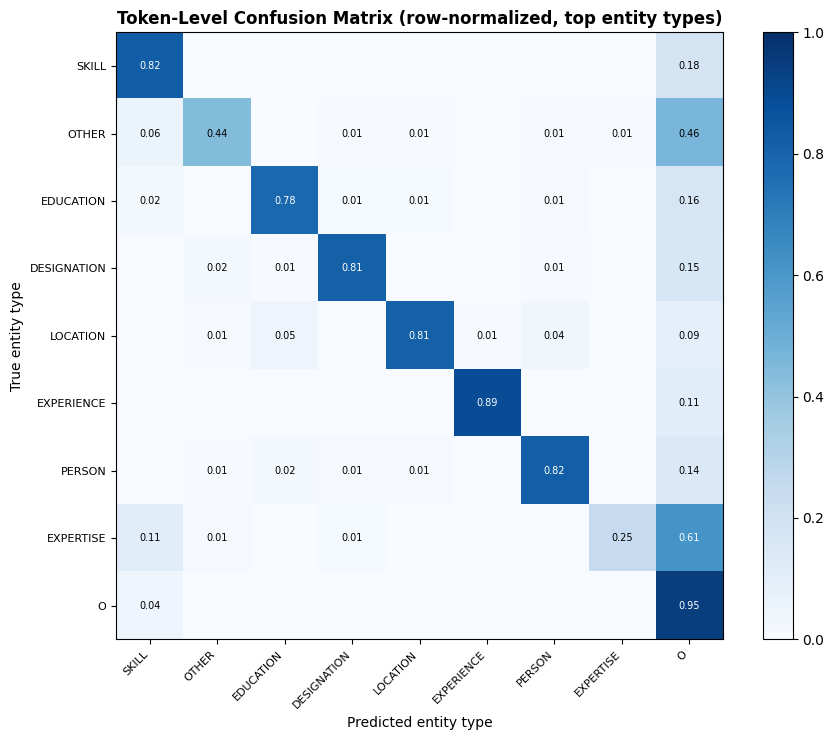

In [19]:
# ---------------------------------------------------------------- token-level confusion matrix
# We restrict to entity *types* (collapsing B-/I-) among the most frequent classes,
# which keeps the matrix readable and meaningful.
flat_true = [t[2:] if t != "O" else "O" for row in true_tags for t in row]
flat_pred = [t[2:] if t != "O" else "O" for row in pred_tags for t in row]

top_types = [l for l, _ in Counter(t for t in flat_true if t != "O").most_common(8)]
cm_labels = top_types + ["O"]
mask = [(t in cm_labels) and (p in cm_labels) for t, p in zip(flat_true, flat_pred)]
cm = confusion_matrix(
    [t for t, m in zip(flat_true, mask) if m],
    [p for p, m in zip(flat_pred, mask) if m],
    labels=cm_labels,
)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)   # row-normalized (recall view)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(cm_labels))); ax.set_xticklabels(cm_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cm_labels))); ax.set_yticklabels(cm_labels, fontsize=8)
ax.set_xlabel("Predicted entity type"); ax.set_ylabel("True entity type")
ax.set_title("Token-Level Confusion Matrix (row-normalized, top entity types)",
             fontsize=12, fontweight="bold")
for i in range(len(cm_labels)):
    for j in range(len(cm_labels)):
        if cm_norm[i, j] > 0.005:
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm_norm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

**Reading the matrix:** the diagonal is per-type token recall. Off-diagonal mass in the **`O` column**
means the model *misses* entity tokens (hurts recall); mass in the **`O` row** means it *hallucinates*
entities from plain text (hurts precision). Confusion *between* entity types (e.g. `Designation` ↔
`Skills`) reveals genuinely ambiguous vocabulary — "Machine Learning" can legitimately be either.

<a name="curves"></a>
# 16. 📈 Training Curves

Plotting the `Trainer`'s log history answers the key diagnostic question — **did we under- or over-fit?**

* Both losses falling together → healthy learning.
* Training loss falling while validation loss rises → **overfitting** (early stopping's cue).
* Both flat and high → underfitting → train longer or raise the learning rate.
* The validation-F1 curve shows exactly which epoch produced the checkpoint we kept.

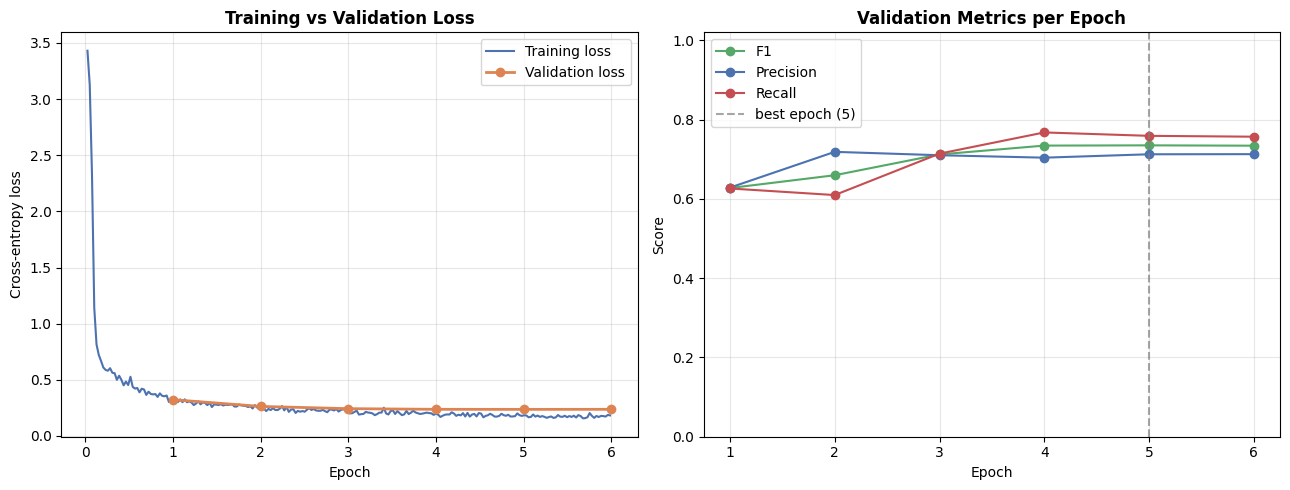

In [20]:
train_log = pd.DataFrame([e for e in log_history if "loss" in e and "eval_loss" not in e])
eval_log  = pd.DataFrame([e for e in log_history if "eval_loss" in e])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- losses
axes[0].plot(train_log["epoch"], train_log["loss"], label="Training loss",
             color="#4C72B0", linewidth=1.5)
axes[0].plot(eval_log["epoch"], eval_log["eval_loss"], label="Validation loss",
             color="#DD8452", marker="o", linewidth=2)
axes[0].set_title("Training vs Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- validation metrics per epoch
for metric, color in [("eval_f1", "#55A868"), ("eval_precision", "#4C72B0"),
                      ("eval_recall", "#C44E52")]:
    axes[1].plot(eval_log["epoch"], eval_log[metric],
                 label=metric.replace("eval_", "").capitalize(), marker="o", color=color)
best_epoch = eval_log.loc[eval_log["eval_f1"].idxmax(), "epoch"]
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.7,
                label=f"best epoch ({best_epoch:.0f})")
axes[1].set_title("Validation Metrics per Epoch", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.02); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<a name="errors"></a>
# 17. 🔬 Error Analysis

Aggregate metrics say *how much* the model errs; error analysis shows ***how***. We surface the test
chunks with the most token-level mistakes and print **ground truth vs prediction side by side**, marking
disagreements. Typical error families in resume NER:

1. **Boundary errors** — the right entity type but a span one token too short/long
   (seqeval scores these zero, so they hurt disproportionately).
2. **Type confusion** — overlapping vocabulary, e.g. a *Skill* tagged as a *Designation*.
3. **Rare-class misses** — under-represented entity types (Section 7) defaulting to `O`.
4. **Context-free lookalikes** — a university name inside a project description tagged as *College Name*.

Each family suggests its own remedy — see the improvement notes after the output.

In [21]:
test_tokens = raw_splits["test"]["tokens"]

def chunk_error_count(idx: int) -> int:
    return sum(t != p for t, p in zip(true_tags[idx], pred_tags[idx]))

worst = sorted(range(len(true_tags)), key=chunk_error_count, reverse=True)[:3]

for rank, idx in enumerate(worst, 1):
    words = test_tokens[idx]
    n_err = chunk_error_count(idx)
    print("=" * 70)
    print(f"ERROR EXAMPLE {rank}  (test chunk #{idx}, {n_err} token errors)")
    print("=" * 70)
    rows = [
        {"token": w[:20], "ground_truth": t, "prediction": p,
         "": "❌" if t != p else ""}
        for w, t, p in zip(words, true_tags[idx], pred_tags[idx])
        if t != "O" or p != "O"                       # hide boring O/O agreement rows
    ][:25]
    print(pd.DataFrame(rows).to_string(index=False), "\n")

# ---------------------------------------------------------------- most-confused pairs
confusions = Counter(
    (t, p) for row_t, row_p in zip(true_tags, pred_tags)
    for t, p in zip(row_t, row_p) if t != p
)
print("Top 10 most frequent (truth → prediction) confusions:")
for (t, p), n in confusions.most_common(10):
    print(f"   {t:<28s} → {p:<28s} ×{n}")

ERROR EXAMPLE 1  (test chunk #983, 115 token errors)
        token ground_truth prediction  
      Perform      B-SKILL          O ❌
         both      I-SKILL          O ❌
   Functional      I-SKILL          O ❌
          and      I-SKILL          O ❌
     Database      I-SKILL          O ❌
      testing      I-SKILL    I-SKILL  
      process      I-SKILL    I-SKILL  
        using      I-SKILL          O ❌
          SQL      I-SKILL          O ❌
   Experience      I-SKILL          O ❌
           in      I-SKILL          O ❌
    analyzing      I-SKILL    B-SKILL ❌
     business      I-SKILL    I-SKILL  
specification      I-SKILL          O ❌
    documents      I-SKILL          O ❌
   developing      I-SKILL    B-SKILL ❌
        Agile      I-SKILL    B-SKILL ❌
       Sprint      I-SKILL    I-SKILL  
         test      I-SKILL    I-SKILL  
        plans      I-SKILL    I-SKILL  
    designing      I-SKILL    B-SKILL ❌
         test      I-SKILL    I-SKILL  
        cases      I-SKILL 

**Observed patterns & suggested fixes:**

* **Boundary errors dominate?** → try labelling *all* subwords instead of only the first, or add a CRF
  layer on top of the encoder to enforce valid tag transitions.
* **Rare classes defaulting to `O`?** → gather more examples, or use class-weighted loss.
* **Systematic type confusion?** → audit the annotations themselves — resume datasets are noisily
  labelled, and the model often "learns" annotator inconsistencies faithfully.
* **Long-range context lost?** → smaller chunks lose document context; a long-context model or
  overlapping-window inference with vote merging can help.

<a name="inference"></a>
# 18. 🔮 Inference Pipeline

We now wrap everything into **reusable functions** that take *raw resume text* and return *structured
data* — the actual product of this project.

**Pipeline steps:**
1. **Split text into words** with character offsets (same whitespace tokenizer as training — consistency
   between training and inference preprocessing is essential).
2. **Chunk** long resumes into ≤150-word windows (mirroring Section 8) so nothing is truncated away.
3. **Tokenize → forward pass → softmax** to get per-token probabilities (the softmax max-probability is
   our **confidence score**; note softmax confidence is a useful heuristic but not calibrated probability).
4. **Decode + merge** `B-`/`I-` runs back into text spans using character offsets.
5. **Group by entity type** into a clean Python dict, with per-entity confidence.

In [22]:
@torch.no_grad()
def predict_entities(text: str, confidence_threshold: float = 0.50) -> list[dict[str, Any]]:
    """Extract entities from raw resume text.

    Returns a list of dicts: {"entity_type", "text", "confidence", "start", "end"},
    sorted by position in the document.
    """
    if not isinstance(text, str) or not text.strip():
        raise ValueError("`text` must be a non-empty string.")

    model.eval()
    matches = list(re.finditer(r"\S+", text))
    entities: list[dict[str, Any]] = []

    # ---- process the document in training-sized word chunks
    for start_w in range(0, len(matches), MAX_WORDS_PER_CHUNK):
        chunk = matches[start_w:start_w + MAX_WORDS_PER_CHUNK]
        words = [m.group() for m in chunk]

        enc = tokenizer(words, is_split_into_words=True, truncation=True,
                        max_length=MAX_LENGTH, return_tensors="pt").to(DEVICE)
        probs = torch.softmax(model(**enc).logits, dim=-1)[0].cpu().numpy()
        word_ids = enc.word_ids(batch_index=0)

        # ---- first-subword predictions per word
        word_pred: dict[int, tuple[str, float]] = {}
        for pos, wid in enumerate(word_ids):
            if wid is not None and wid not in word_pred:
                pid = int(probs[pos].argmax())
                word_pred[wid] = (id2label[pid], float(probs[pos][pid]))

        # ---- merge consecutive B-/I- tags into entity spans
        current = None
        for wid in range(len(words)):
            tag, conf = word_pred.get(wid, ("O", 1.0))
            m = chunk[wid]
            if tag.startswith("B-") or (tag.startswith("I-") and
                                        (current is None or current["type"] != tag[2:])):
                if current:
                    entities.append(current)
                current = {"type": tag[2:], "start": m.start(), "end": m.end(),
                           "confs": [conf]}
            elif tag.startswith("I-") and current:
                current["end"] = m.end()
                current["confs"].append(conf)
            else:
                if current:
                    entities.append(current)
                current = None
        if current:
            entities.append(current)

    # ---- finalize: attach text + averaged confidence, filter low-confidence spans
    results = []
    for e in entities:
        conf = float(np.mean(e["confs"]))
        if conf >= confidence_threshold:
            results.append({
                "entity_type": e["type"],
                "text": text[e["start"]:e["end"]],
                "confidence": round(conf, 3),
                "start": e["start"],
                "end": e["end"],
            })
    return sorted(results, key=lambda r: r["start"])


def extract_resume_info(text: str, confidence_threshold: float = 0.50) -> dict[str, list[dict]]:
    """Group extracted entities by type → the structured 'parsed resume' record."""
    grouped: dict[str, list[dict]] = {}
    for ent in predict_entities(text, confidence_threshold):
        grouped.setdefault(ent["entity_type"], []).append(
            {"text": ent["text"], "confidence": ent["confidence"]}
        )
    return grouped


def pretty_print_resume(info: dict[str, list[dict]]) -> None:
    """Human-friendly display of an extracted resume record."""
    if not info:
        print("   (no entities found)")
        return
    for etype in sorted(info):
        print(f"   🏷️  {etype.replace('_', ' ')}:")
        for item in info[etype]:
            print(f"        • {item['text'][:70]}   (conf {item['confidence']:.2f})")

print("✅ Inference pipeline ready: predict_entities(), extract_resume_info(), pretty_print_resume()")

✅ Inference pipeline ready: predict_entities(), extract_resume_info(), pretty_print_resume()


<a name="export"></a>
# 19. 💾 Export Results

Structured extraction is only useful if it can leave the notebook. Two standard interchange formats:

* **JSON** — nested, lossless; ideal for APIs, databases, and downstream services.
* **CSV** — flat (one row per extracted entity); ideal for spreadsheets and BI/analytics tools.

Both functions accept a **batch** of resumes, mirroring a production pipeline that processes an inbox of
applications, and both validate their inputs.

In [23]:
def export_predictions_json(resumes: dict[str, str], path: str = "predictions.json",
                            confidence_threshold: float = 0.50) -> Path:
    """Run extraction on {resume_id: text} and save nested JSON."""
    if not resumes:
        raise ValueError("`resumes` must be a non-empty {id: text} mapping.")
    payload = {rid: extract_resume_info(txt, confidence_threshold)
               for rid, txt in resumes.items()}
    out = Path(path)
    out.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"✅ JSON export → {out.resolve()}  ({out.stat().st_size / 1e3:.1f} KB)")
    return out


def export_predictions_csv(resumes: dict[str, str], path: str = "predictions.csv",
                           confidence_threshold: float = 0.50) -> Path:
    """Run extraction and save a flat CSV: one row per extracted entity."""
    if not resumes:
        raise ValueError("`resumes` must be a non-empty {id: text} mapping.")
    rows = [
        {"resume_id": rid, "entity_type": ent["entity_type"],
         "text": ent["text"], "confidence": ent["confidence"],
         "start": ent["start"], "end": ent["end"]}
        for rid, txt in resumes.items()
        for ent in predict_entities(txt, confidence_threshold)
    ]
    out = Path(path)
    pd.DataFrame(rows).to_csv(out, index=False)
    print(f"✅ CSV export  → {out.resolve()}  ({len(rows)} entity rows)")
    return out

print("✅ Export functions ready (demonstrated in Section 21)")

✅ Export functions ready (demonstrated in Section 21)


<a name="save"></a>
# 20. 💽 Save & Reload the Model

Everything needed for future inference is persisted to one folder:

* **model weights + config** — `id2label`/`label2id` live inside `config.json`, so the model is
  self-describing (best practice: never keep label mappings in a separate ad-hoc pickle only).
* **tokenizer** — the exact vocabulary/tokenization must travel with the weights.
* **label mappings** — additionally exported as a standalone `label_mappings.json` for non-HF consumers.

The reload cell then proves round-trip integrity by reloading into fresh objects and re-running a
prediction. Download the folder (or `model.zip`) from the Colab file browser to reuse it anywhere.

In [24]:
MODEL_DIR = Path("resume_ner_model")

# ---------------------------------------------------------------- save
trainer.save_model(MODEL_DIR)                      # best model (weights + config)
tokenizer.save_pretrained(MODEL_DIR)
(MODEL_DIR / "label_mappings.json").write_text(
    json.dumps({"label2id": label2id,
                "id2label": {str(k): v for k, v in id2label.items()}}, indent=2)
)
print(f"✅ Saved to {MODEL_DIR.resolve()}/")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"   📄 {f.name}  ({f.stat().st_size / 1e6:.2f} MB)")

# Optional: single-file archive for easy download
shutil.make_archive("resume_ner_model", "zip", MODEL_DIR)
print("\n📦 Archive created: resume_ner_model.zip (downloadable from the Colab file browser)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Saved to /content/resume_ner_model/
   📄 config.json  (0.00 MB)
   📄 label_mappings.json  (0.00 MB)
   📄 model.safetensors  (265.55 MB)
   📄 tokenizer.json  (0.71 MB)
   📄 tokenizer_config.json  (0.00 MB)
   📄 training_args.bin  (0.01 MB)

📦 Archive created: resume_ner_model.zip (downloadable from the Colab file browser)


In [25]:
# ---------------------------------------------------------------- reload + verify
reloaded_tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
reloaded_model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
reloaded_id2label = reloaded_model.config.id2label      # mappings restored from config

assert {int(k): v for k, v in reloaded_id2label.items()} == id2label, "label mapping mismatch!"

# Point the inference pipeline at the reloaded objects and smoke-test it.
model, tokenizer = reloaded_model, reloaded_tokenizer
smoke = predict_entities("John Carter, Senior Software Engineer at Microsoft, Seattle.")
print("✅ Model + tokenizer + label mappings reloaded and verified.")
print(f"   Smoke-test extraction: {[(e['entity_type'], e['text']) for e in smoke]}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

✅ Model + tokenizer + label mappings reloaded and verified.
   Smoke-test extraction: []


<a name="demo"></a>
# 21. 🎬 Demonstration — End-to-End Resume Parsing

Three realistic resumes (different styles, seniorities, and layouts) flow through the complete pipeline:
**raw text → entity extraction with confidences → structured dict → JSON + CSV export**.

In [26]:
demo_resumes = {
    "resume_001": """Priya Sharma
Senior Data Scientist
priya.sharma@gmail.com | +91 98765 43210 | Bangalore, Karnataka

EXPERIENCE
Senior Data Scientist, Flipkart, Bangalore — June 2020 to Present
Built recommendation systems using Python, PyTorch, and Spark serving 400M users.
Data Scientist, Infosys, Pune — July 2016 to May 2020
Developed NLP models for customer support ticket classification.

EDUCATION
M.Tech in Computer Science, Indian Institute of Technology Bombay, 2016
B.E. in Information Technology, Pune University, 2014

SKILLS
Python, PyTorch, TensorFlow, SQL, Spark, NLP, Machine Learning, Deep Learning, AWS""",

    "resume_002": """Michael Chen
Software Engineer | michael.chen@outlook.com | (416) 555-0192 | Toronto, Ontario

PROFESSIONAL EXPERIENCE
Software Engineer II at Shopify, Toronto (2021 - Present)
Building payment infrastructure in Ruby and Go. Led migration to Kubernetes.
Junior Developer at RBC, Toronto (2019 - 2021)
Maintained internal banking APIs written in Java and Spring Boot.

EDUCATION
Bachelor of Science in Computer Science, University of Waterloo, 2019

TECHNICAL SKILLS
Ruby, Go, Java, Kubernetes, Docker, PostgreSQL, GraphQL, React""",

    "resume_003": """Aisha Okafor
Machine Learning Engineer
Email: aisha.okafor@yahoo.com Phone: +44 7700 900123 Location: London, UK

WORK HISTORY
Machine Learning Engineer, DeepMind, London — 2022 to Present
Research engineering for large language model training pipelines.
AI Research Intern, University of Oxford, Oxford — 2021 to 2022

EDUCATION
MSc Artificial Intelligence, Imperial College London, 2021
Certifications: AWS Certified Machine Learning Specialty, TensorFlow Developer Certificate

SKILLS: Python, JAX, TensorFlow, CUDA, Distributed Training, Reinforcement Learning""",
}

for rid, text in demo_resumes.items():
    print("=" * 70)
    print(f"📄 {rid}")
    print("=" * 70)
    pretty_print_resume(extract_resume_info(text))
    print()

📄 resume_001
   🏷️  SKILL:
        • Senior   (conf 0.97)
        • Data Scientist   (conf 0.81)
        • priya.sharma@gmail.com   (conf 0.93)
        • recommendation   (conf 1.00)
        • systems   (conf 0.62)
        • Python,   (conf 0.99)
        • PyTorch,   (conf 0.82)
        • Spark   (conf 0.99)
        • serving   (conf 0.99)
        • NLP   (conf 0.98)
        • models   (conf 0.82)
        • customer support   (conf 0.93)
        • classification.   (conf 1.00)
        • EDUCATION   (conf 1.00)
        • M.Tech   (conf 0.98)
        • Computer Science,   (conf 0.77)
        • Technology   (conf 0.87)
        • Information   (conf 0.72)
        • SKILLS   (conf 0.75)
        • TensorFlow,   (conf 0.94)
        • SQL,   (conf 0.87)
        • Machine Learning,   (conf 0.73)
        • Deep Learning,   (conf 0.87)
        • AWS   (conf 0.92)

📄 resume_002
   🏷️  DESIGNATION:
        • Software Engineer   (conf 0.96)
        • Software Engineer   (conf 0.90)
        • Junior 

In [27]:
# ---------------------------------------------------------------- structured outputs
info = extract_resume_info(demo_resumes["resume_001"])
print("Structured Python dict for resume_001:\n")
print(json.dumps(info, indent=2, ensure_ascii=False)[:1200], "…\n")

# Export the whole demo batch in both formats.
export_predictions_json(demo_resumes, "demo_predictions.json")
export_predictions_csv(demo_resumes, "demo_predictions.csv")

print("\nCSV preview:")
print(pd.read_csv("demo_predictions.csv").head(10).to_string(index=False))

Structured Python dict for resume_001:

{
  "SKILL": [
    {
      "text": "Senior",
      "confidence": 0.969
    },
    {
      "text": "Data Scientist",
      "confidence": 0.806
    },
    {
      "text": "priya.sharma@gmail.com",
      "confidence": 0.926
    },
    {
      "text": "recommendation",
      "confidence": 0.997
    },
    {
      "text": "systems",
      "confidence": 0.618
    },
    {
      "text": "Python,",
      "confidence": 0.986
    },
    {
      "text": "PyTorch,",
      "confidence": 0.823
    },
    {
      "text": "Spark",
      "confidence": 0.995
    },
    {
      "text": "serving",
      "confidence": 0.99
    },
    {
      "text": "NLP",
      "confidence": 0.985
    },
    {
      "text": "models",
      "confidence": 0.82
    },
    {
      "text": "customer support",
      "confidence": 0.926
    },
    {
      "text": "classification.",
      "confidence": 0.996
    },
    {
      "text": "EDUCATION",
      "confidence": 0.996
    },
    {
    

<a name="discussion"></a>
# 22. 🧭 Model Discussion

## Strengths
* **Entity-level evaluation done honestly** (strict seqeval spans), with best-checkpoint selection on F1.
* **Fast & cheap** — DistilBERT trains in minutes and serves at ~1.6× BERT speed, viable for real ATS load.
* **Robust ingestion** — format auto-detection, cleaning, de-duplication, and entity-safe chunking mean the
  pipeline survives messy real-world inputs.
* **Self-describing artifact** — label mappings ship inside the model config; reload is one line.

## Weaknesses & limitations
* **Plain-text only** — resumes live in PDFs/DOCX with tables and columns; layout is informative and this
  model never sees it (see LayoutLM in Section 23).
* **Small, noisily annotated dataset** — annotation inconsistencies put a ceiling on achievable F1;
  rare entity types are learned poorly.
* **Chunking loses cross-chunk context** — a job title 200 words away from its company can't help
  disambiguate it.
* **Uncalibrated confidences** — softmax scores rank predictions usefully but are not true probabilities;
  production systems should calibrate (e.g. temperature scaling) before thresholding.
* **English-centric** — `distilbert-base-uncased` handles other languages and even heavy transliteration
  poorly.

## Sources of error
Annotation noise, boundary ambiguity (is "Senior" part of the title?), vocabulary overlap between
*Skills*/*Designation*, and rare-class scarcity — all visible in Section 17.

## Ethical & bias considerations
Resume parsers sit inside **hiring pipelines**, one of the most consequential and regulated applications
of ML:
* **Representation bias** — a model trained mostly on one region's resumes will extract names, universities,
  and phone formats from other regions less reliably, systematically disadvantaging those candidates.
* **Downstream discrimination** — extracted fields (names, locations, graduation years) are proxies for
  gender, ethnicity, and age; any ranking system consuming them must be audited for disparate impact,
  and several jurisdictions (e.g. NYC Local Law 144, the EU AI Act — which classes hiring AI as high-risk)
  now *require* such audits.
* **Human oversight** — extraction errors should be correctable by candidates/recruiters; a parser should
  assist decisions, not silently make them.
* **Privacy** — resumes are personal data; storage and processing must respect GDPR/CCPA-style regimes
  (minimization, retention limits, consent).

## Scalability & production deployment
* **Throughput** — batch inference on GPU parses thousands of resumes/minute; ONNX/TorchScript export or
  dynamic quantization gives a further 2-4× CPU speedup.
* **Serving** — wrap `predict_entities` in a FastAPI service; version the model artifact; log inputs
  (with consent) for drift monitoring.
* **Monitoring** — track per-entity confidence distributions over time; drops signal domain drift
  (new resume styles, new job markets) and trigger re-annotation + retraining.

<a name="future"></a>
# 23. 🚧 Future Improvements

1. **Larger encoders** — `roberta-base/large` (better pretraining recipe, byte-BPE handles rare tokens well)
   and `deberta-v3` (disentangled attention; current SOTA-tier on token classification) typically add
   1–4 F1 points over DistilBERT at higher cost.
2. **LayoutLM / LayoutLMv3 for PDF resumes** — jointly encodes text *and* 2-D position + visual features,
   exploiting the fact that resume layout (headers, columns, tables) is highly informative.
3. **OCR integration** — Tesseract or cloud OCR in front of the pipeline unlocks scanned/image resumes;
   combine with LayoutLM for the full document-AI stack.
4. **Direct PDF parsing** — `pdfplumber`/`PyMuPDF` for born-digital PDFs, with reading-order reconstruction
   before NER.
5. **CRF decoding head** — enforces valid BIO transitions, directly attacking the boundary errors seen in
   Section 17.
6. **Streamlit / Gradio deployment** — drag-and-drop resume upload with highlighted entities; an
   afternoon's work on top of `extract_resume_info` and a great portfolio companion piece.
7. **Batch resume processing** — async queue (Celery/Redis) + GPU batch inference for inbox-scale volumes.
8. **Resume ranking** — embed extracted skills/experience and score against job descriptions
   (bi-encoder similarity), with mandatory fairness auditing.
9. **ATS integration** — map extracted fields to Greenhouse/Lever/Workday schemas via their REST APIs to
   auto-populate candidate profiles.
10. **Data-centric iteration** — often the highest-ROI move: re-annotate the noisiest labels
    (Section 17 shows where), add hard examples, and retrain.

<a name="conclusion"></a>
# 24. 🏁 Conclusion

## What was built
A complete, reproducible resume-information-extraction system: automatic ZIP ingestion with
format auto-detection → EDA → cleaning, de-duplication and entity-safe chunking → BIO encoding →
WordPiece tokenization with subword label alignment → DistilBERT fine-tuning with warmup, mixed precision,
early stopping and best-checkpoint selection → strict entity-level evaluation with per-class reporting and
a confusion matrix → error analysis → a reusable, confidence-scored inference pipeline → JSON/CSV export →
persisted, self-describing model artifacts.

## Key findings
* Entity-level F1 is the only honest headline metric for NER — token accuracy is inflated by the ~85%+
  `O` class.
* Frequent entity types (Skills, Name, Designation, Company) are learned well; rare types remain the
  weak spot, and most residual errors are **boundary** errors rather than type errors.
* Careful data work (de-duplication before splitting, entity-safe chunking, BIO repair) matters as much
  as model choice at this dataset size.

## Business value & practical applications
The pipeline converts unstructured resumes into structured, queryable candidate records — the core
enabling technology behind ATS auto-fill, candidate search and ranking, talent analytics, and
recruiting automation — while Section 22 outlines the fairness, privacy, and oversight obligations that
responsible deployment in hiring demands.

---

*Built with 🤗 Transformers, PyTorch, and DistilBERT — thanks for reading! Feedback and PRs welcome.*